<h3 style="color:red"><b>Importante:</b></h3>Nuestro desarrollo comienza después del enunciado.

### Integrantes:

<p style="color:teal">Noah Ancalao</p>
<p style="color:magenta">Cristóbal Manríquez</p>

___ 

# Tarea 2: Predicción de redshift fotométrico con métodos de ensamble

## Contexto

El redshift de una galaxia es una cantidad fundamental para estudiar distancias cosmológicas y evolución de galaxias. Idealmente, el redshift se mide mediante espectroscopía, pero obtener espectros para grandes muestras puede ser costoso en tiempo de observación.

Una alternativa ampliamente usada en astronomía es estimar redshifts fotométricos a partir de magnitudes medidas en distintos filtros. En esta actividad trabajaremos con un catálogo de galaxias que contiene fotometría multibanda y redshifts espectroscópicos de referencia. El objetivo será entrenar modelos de machine learning capaces de predecir el redshift usando información fotométrica.

La actividad se plantea como una competencia tipo **Kaggle**: cada grupo entrenará sus modelos con un conjunto de entrenamiento y deberá generar predicciones para un conjunto de test oculto. El ranking final se calculará usando el MSE sobre ese conjunto de test.

A diferencia del notebook que hicimos en clase (donde el dataset ya venía preparado), acá van a recibir el catálogo sin procesar. Van a tener que aplicar tú mismo/a las herramientas de diagnóstico que practicamos  (limpieza de datos, elección de modelo, optimización de hiperparámetros, comparación de criterios de feature importance) sin que nadie te diga de antemano qué decisiones tomar.

---

## Objetivo

Entrenar, comparar y optimizar modelos de regresión basados en árboles y métodos de ensamble para predecir el redshift de galaxias.

El criterio principal de evaluación será el error cuadrático medio:

$$
MSE = \frac{1}{N}\sum_i (z_{{\rm pred},i} - z_{{\rm true},i})^2
$$

El objetivo práctico será obtener el menor MSE posible en el conjunto de test oculto.

---

## Datos

Se entregarán tres archivos:

1. `train_redshift.csv`: contiene las variables fotométricas y el redshift de referencia.
2. `test_redshift.csv`: contiene las mismas variables fotométricas, pero no incluye el redshift.
3. `sample_submission.csv`: muestra el formato esperado para la entrega de predicciones.

El archivo de entrenamiento contiene magnitudes corregidas por apertura en distintos filtros. El redshift de referencia está en la columna: $z_{\rm helio}$

En el archivo de test, esta columna no estará disponible.

---

## Instrucciones generales

Deben desarrollar un notebook reproducible en Python que incluya:

1. Exploración inicial del conjunto de entrenamiento.
2. Preparación de los datos para modelamiento.
3. Construcción o selección de variables predictoras.
4. Separación interna entre entrenamiento y validación, o uso de validación cruzada.
5. Entrenamiento de un modelo baseline con `DecisionTreeRegressor`.
6. Entrenamiento de algún método de ensamble, por ejemplo:

   * `RandomForestRegressor`
   * `ExtraTreesRegressor`
   * `GradientBoostingRegressor`
   * `HistGradientBoostingRegressor`
   * otro método justificado.
7. Optimización de hiperparámetros (puede usar GridSearchCV, RandomizedSearchCV, Optuna, etc)
8. Comparación de modelos usando MSE.
9. Selección del modelo final.
10. Generación de predicciones para `test_redshift.csv`.

El catálogo entregado no está completamente procesado. Parte del trabajo consiste en revisar valores faltantes, valores anómalos y decidir qué variables utilizar o construir. 

El conjunto de test no contiene el redshift verdadero. Por lo tanto, no puede ser usado para evaluar ni ajustar modelos. La selección de modelos e hiperparámetros debe realizarse usando únicamente el conjunto de entrenamiento. Pueden crear un conjunto de validación interno (a partir del set de entrenamiento) para la optimización de hiperparámetros, pero el ranking final se calculará de forma ciega, evaluando sus predicciones directamente sobre test_redshift.csv

---

## Entrega de predicciones

Cada grupo debe entregar un archivo llamado:

```text
predicciones.csv
```

con exactamente dos columnas:

| objno_deep2 | z_pred |
| ----------- | ------ |
|             |        |
|             |        |
|             |        |

La columna `objno_deep2` debe coincidir con los identificadores del archivo `test_redshift.csv`.

La columna `z_pred` debe contener el redshift predicho por el modelo final.

El archivo debe tener una predicción para cada objeto del conjunto de test.

El archivo `sample_submission.csv` muestra el formato exacto que debe tener la entrega final. Deben reemplazar los valores de la columna `z_pred` por las predicciones de su modelo, manteniendo los mismos identificadores `objno_deep2`.

---
## Métricas de evaluación

La métrica principal de la competencia será el error cuadrático medio:

$$
MSE = \frac{1}{N}\sum_i (z_{{\rm pred},i} - z_{{\rm spec},i})^2
$$

Además, deberán reportar dos métricas comúnmente usadas en estudios de redshifts fotométricos.

Primero, definimos el residuo normalizado:

$$
\Delta z_i = \frac{z_{{\rm spec},i} - z_{{\rm pred},i}}{1 + z_{{\rm spec},i}}
$$

La dispersión robusta de los residuos se calculará mediante la normalized median absolute deviation:

$$
\sigma_{\rm NMAD} = 1.48 \times {\rm median}\left(
\left| \Delta z_i - {\rm median}(\Delta z) \right|
\right)
$$

También se calculará la fracción de outliers:

$$
\eta = \frac{N_{\rm outliers}}{N}
$$

donde se considera outlier a todo objeto que cumple:

$$
\frac{|z_{\rm spec} - z_{\rm pred}|}{1 + z_{\rm spec}} > 0.15
$$

El ranking de la competencia se calculará usando el MSE sobre el conjunto de test oculto. Sin embargo, en el notebook deben reportar e interpretar las tres métricas: MSE, $\sigma_{\rm NMAD}$ y $\eta$.



## Resultado esperado en el notebook

El notebook debe incluir una tabla resumen similar a la siguiente:

| Modelo        | Features usadas | Hiperparámetros principales | MSE train | MSE validación |
| ------------- | --------------- | --------------------------- | --------- | -------------- |
| Decision Tree |                 |                             |           |                |
| Ensemble      |                 |                             |           |                |

Además, deben incluir:

* un gráfico de $z_{\rm true}$ vs. $z_{\rm pred}$ usando datos de validación
* un análisis de los errores del modelo
* un análisis de las métricas obtenidas
* una discusión sobre las variables más relevantes
* una conclusión justificando el modelo final escogido

---

## Preguntas finales
Respondan brevemente al final del notebook. En todas las preguntas, la respuesta debe apoyarse en gráficos o números específicos de su propio notebook, no en generalidades.

**Sobre la comparación de modelos:**

1. ¿Qué modelo obtuvo el menor MSE en validación?
2. ¿Ese modelo fue elegido como modelo final? Justifiquen.
3. ¿Qué diferencias observaron entre un árbol individual y los métodos de ensamble?

**Sobre las variables:**

4. ¿Qué variables parecen ser más importantes para predecir el redshift?
5. Calculen la importancia de variables con al menos dos criterios distintos (por ejemplo, MDI y permutation importance). ¿Coinciden en el ranking? Si no coinciden, ¿a qué atribuyen la diferencia?

**Sobre los errores del modelo:**

6. ¿En qué rangos de redshift falla más el modelo?
7. En el notebook de clase vimos que los métodos basados en árboles tienden a "estrechar" la distribución de predicciones (sobreestiman z bajos, subestiman z altos). ¿Observan este mismo efecto en su propio scatter $z_{\rm true}$
 vs. $z_{\rm pred}$? ¿En qué rango es más pronunciado, y coincide con una menor cantidad de galaxias de entrenamiento en ese rango?
8. Si usaron oob_score en algún modelo, comparen ese valor con el de su validación cruzada. ¿Son consistentes? ¿Qué les dice eso sobre la confiabilidad de OOB para este dataset en particular?

**Sobre el proceso:**

9. ¿Qué posibles fuentes de error o sesgo puede tener este enfoque?
10. ¿Qué decisión metodológica tuvo mayor impacto en el resultado final?
11. ¿El modelo con menor MSE es necesariamente el mejor modelo desde el punto de vista científico? Justifiquen.


---

## Restricciones importantes

No se permite usar información externa al archivo entregado para predecir el redshift del conjunto de test.

No se debe modificar manualmente el archivo de predicciones para objetos individuales.

No se debe usar el conjunto de test para ajustar hiperparámetros ni tomar decisiones de modelamiento. El test oculto se usará solo para la evaluación final.

---

## Entregables

Cada grupo debe entregar:

1. Notebook reproducible en Python.
2. Archivo `predicciones.csv` con las predicciones para el conjunto de test.
3. Breve conclusión final dentro del notebook.

La evaluación considerará tanto el desempeño predictivo como la calidad del procedimiento. El notebook debe ser claro y explicativo del proceso.  El ranking se calculará usando el MSE sobre el conjunto de test oculto, pero la nota no dependerá únicamente del ranking.


___
# Desarrollo
## Importamos librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Exploración inicial de los datos

In [2]:
data = pd.read_csv("train_redshift.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 19057 entries, 0 to 19056
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   objno_deep2    19057 non-null  int64  
 1   ra_deep2       19057 non-null  float64
 2   dec_deep2      19057 non-null  float64
 3   zquality       19057 non-null  int64  
 4   u_apercor      19057 non-null  float64
 5   g_apercor      19057 non-null  float64
 6   r_apercor      19057 non-null  float64
 7   i_apercor      19057 non-null  float64
 8   i2_apercor     19057 non-null  float64
 9   z_apercor      19057 non-null  float64
 10  flag_cfhtls    19057 non-null  int64  
 11  cfhtls_source  19057 non-null  int64  
 12  subaru_source  19057 non-null  int64  
 13  zhelio         19057 non-null  float64
dtypes: float64(9), int64(5)
memory usage: 2.0 MB


Como podemos ver, el set de entrenamiento no tiene datos NaN como tal.

In [3]:
data.describe()

,objno_deep2,ra_deep2,dec_deep2,zquality,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor,flag_cfhtls,cfhtls_source,subaru_source,zhelio
count,1.905700e+04,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000
mean,1.250061e+07,214.775328,52.802919,3.102902,23.072000,22.072399,21.474566,21.037788,-22.943618,20.808852,22.200714,-1.924227,-47.986567,0.714946
std,9.721234e+05,0.601017,0.415641,1.313585,21.588971,20.738837,20.670669,20.667991,59.776041,20.659574,76.125181,14.914514,49.629275,0.417994
min,1.100167e+07,213.473160,51.929113,-2.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-0.078525
25%,1.200843e+07,214.310464,52.476931,2.000000,23.671897,23.237811,22.598163,22.014806,-99.000000,21.711408,0.000000,0.000000,-99.000000,0.396693
50%,1.300380e+07,214.782577,52.810978,4.000000,24.323693,23.911843,23.415690,22.912288,21.885385,22.634205,0.000000,0.000000,0.000000,0.688533
75%,1.304796e+07,215.223139,53.111788,4.000000,25.003003,24.439543,23.896741,23.498121,23.242554,23.295065,0.000000,1.000000,0.000000,0.979685
max,1.410175e+07,216.098062,53.694992,4.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,253.000000,1.000000,1.000000,4.500611


Dicho eso, el `describe`, usado aquí nos muestra que todas las fotometrías de apertura tienen un valor mínimo de -99 y un máximo de 99, que nos lleva a que son valores de relleno para casos con datos anómalos o fallidos (equivalente a un NaN).
Vamos a buscar los percentiles 5 y 95, para ver si hay un cambio suave al valor extremo o no.

In [4]:
data.quantile([0.05,0.95])

,objno_deep2,ra_deep2,dec_deep2,zquality,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor,flag_cfhtls,cfhtls_source,subaru_source,zhelio
0.05,11021692.8,213.798886,52.119977,1.0,21.988241,21.186309,20.377924,19.913289,-99.000000,19.667335,0.0,0.0,-99.0,0.106477
0.95,14028087.4,215.777156,53.499965,4.0,26.844048,25.417368,24.747409,24.454590,24.280751,24.336552,244.0,1.0,1.0,1.404895


Podemos ver que esto funciona bien para la mayoría de las columnas excepto `i2_apercor` y `subaru_source`. Las columnas con el sufijo *source* parecen ser *flags* de donde vienen los datos, y por lo tanto, quitarlas del set de entrenamiento no debería afectar fuertemente las predicciones. Una mirada directa al archivo de los datos nos muestra que en general las filas con valores inválidos tienen valores inválidos en la mayoría de las columnas.

De aquí surge la idea de reemplazar los valores inválidos con NaN y luego eliminar las filas con al menos dos columnas sin datos.

## Preparación de los datos (NaN handling)

In [5]:
cols = list(data.columns)[4:-4] # lista con los nombres de las columnas con fotometría
cols

['u_apercor', 'g_apercor', 'r_apercor', 'i_apercor', 'i2_apercor', 'z_apercor']

In [6]:
data_cleaning=data[cols].replace({-99.0:np.nan,99.0:np.nan}) # reemplazamos los valores extremos con NaNs
data_cleaning.info()

<class 'pandas.DataFrame'>
RangeIndex: 19057 entries, 0 to 19056
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   u_apercor   18222 non-null  float64
 1   g_apercor   18333 non-null  float64
 2   r_apercor   18336 non-null  float64
 3   i_apercor   18332 non-null  float64
 4   i2_apercor  11708 non-null  float64
 5   z_apercor   18331 non-null  float64
dtypes: float64(6)
memory usage: 893.4 KB


In [7]:
data_cleaning.dropna(thresh=4,inplace=True) # que la fila tenga al menos 4 valores reales
data_cleaning.info()

<class 'pandas.DataFrame'>
Index: 18331 entries, 0 to 19056
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   u_apercor   18218 non-null  float64
 1   g_apercor   18331 non-null  float64
 2   r_apercor   18331 non-null  float64
 3   i_apercor   18331 non-null  float64
 4   i2_apercor  11708 non-null  float64
 5   z_apercor   18329 non-null  float64
dtypes: float64(6)
memory usage: 1002.5 KB


In [8]:
print(f"El porcentaje de datos en i2_apercor que es nan es: {(1-(11708/18331))*100:.3f}%")

El porcentaje de datos en i2_apercor que es nan es: 36.130%


Esto plantea un gran problema: ¿Cómo lidiar con esos datos nulos?

Hay 3 opciones principales:
- Eliminar las filas donde el valor es inválido, perdiendo alrededor de un 40% de la muestra total.
- Rellenar con valores mínimos o máximos dependiendo del signo del dato original, y cualquier otra información que obtengamos.
- Directamente deshechar la columna.

Antes de tomar una decisión, sería bueno mirar la correlación de los datos.

In [9]:
data_corrs = data.replace({-99.0:np.nan,99.0:np.nan}).dropna(thresh=11)[list(data.columns)[3::]]
data_corrs.info()

<class 'pandas.DataFrame'>
Index: 18334 entries, 0 to 19056
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   zquality       18334 non-null  int64  
 1   u_apercor      18220 non-null  float64
 2   g_apercor      18333 non-null  float64
 3   r_apercor      18334 non-null  float64
 4   i_apercor      18332 non-null  float64
 5   i2_apercor     11708 non-null  float64
 6   z_apercor      18330 non-null  float64
 7   flag_cfhtls    18334 non-null  float64
 8   cfhtls_source  18334 non-null  float64
 9   subaru_source  9600 non-null   float64
 10  zhelio         18334 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 1.7 MB


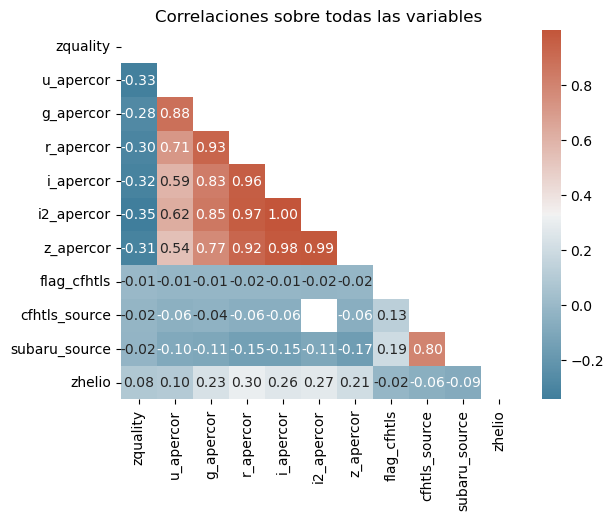

In [10]:
corrs = data_corrs.corr()
import seaborn as sns
fig, ax = plt.subplots()
mask = np.triu(np.ones_like(corrs,dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corrs, mask=mask, ax=ax, annot=True, fmt=".2f",cmap=cmap)
ax.set(title="Correlaciones sobre todas las variables")
plt.show()
del data_corrs # limpiando variables que no se vuelven a usar

Podemos observar del gráfico que las bandas `i` e `i2` están muy fuertemente correlacionadas, lo que tiene sentido porque presumiblemente son la misma banda fotométrica.
Esto nos dice, entre otras cosas, que la información contenida en una puede ser corroborada con la otra. Y que descartar una de ellas tampoco representaría una pérdida extrema de datos.
Por lo mismo, vamos a probar nuestro modelo baseline con dos opciones:
1. Un set recortado tal que no hayan NaNs en `i2_apercor`
2. Un set sin recortar, sin `i2_apercor` y sin otros NaN

Por la presencia de datos _outliers_ se realiza un _clipping_ para tomar los valores entre los percentiles 5 y 95.

In [11]:
data_clean1 = data.merge(data_cleaning.dropna(how="any"))[cols+["zquality","zhelio"]]#eliminamos filas con al menos un nan
thresh = data_clean1.quantile([0.05,0.95]).values
data_clean1.clip(thresh[0],thresh[1], inplace=True)

,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor,zquality,zhelio
0,25.536802,25.355573,24.760224,24.457204,24.482340,24.316455,1,1.483316
1,23.802174,23.591218,23.290410,22.990565,23.018509,22.496892,4,1.314826
2,23.661166,22.389709,21.359927,20.786062,20.839287,20.466936,4,0.297696
3,24.590983,23.872463,23.713001,23.670067,23.628797,23.663545,2,1.159324
4,24.374535,24.226175,23.892377,23.263941,23.267458,22.990853,4,0.811566
...,...,...,...,...,...,...,...,...
11660,25.699471,24.816155,23.969305,23.693668,23.705583,23.558330,4,0.358532
11661,25.981709,25.355573,24.760224,24.457204,24.482340,24.316455,1,0.163124
11662,23.847550,23.730496,23.579372,23.205144,23.191520,22.762498,3,1.105199
11663,24.848810,24.480684,24.386084,24.294300,24.270368,24.316455,1,0.193226


In [12]:
data_clean2=data.replace({-99.0:np.nan,99.0:np.nan} # convertimos a nan para que se reconozcan como iguales
).merge(data_cleaning # inner join
)[cols[0:-2]+["z_apercor","zquality","zhelio"]].dropna(how="any") # seleccionamos las col, borramos los nan restantes
thresh = data_clean2.quantile([0.05,0.95]).values
#del data_cleaning # cleanup
data_clean2.clip(thresh[0],thresh[1],inplace=True)

,u_apercor,g_apercor,r_apercor,i_apercor,z_apercor,zquality,zhelio
0,25.536802,25.239820,24.566358,24.256687,24.149097,1,1.401917
1,23.802174,23.591218,23.290410,22.990565,22.496892,4,1.314826
2,23.661166,22.389709,21.359927,20.786062,20.466936,4,0.297696
3,24.590983,23.872463,23.713001,23.670067,23.663545,2,1.159324
4,24.374535,24.226175,23.892377,23.263941,22.990853,4,0.811566
...,...,...,...,...,...,...,...
18326,24.240796,24.205122,23.926456,23.528897,22.909429,4,0.828503
18327,26.404143,25.084797,23.840316,23.301013,23.286571,1,0.373158
18328,23.596916,22.994620,22.683025,22.793867,22.622676,1,0.253488
18329,24.128220,23.855998,23.652930,23.422120,23.146123,4,1.401917


## Validación Cruzada

In [13]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score, ShuffleSplit, cross_validate
# separamos features y resultados
# muestra 1
X1 = data_clean1[list(data_clean1.columns)[0:-1]]
y1 = data_clean1["zhelio"]
#muestra 2
X2 = data_clean2[list(data_clean2.columns)[0:-1]]
y2 = data_clean2["zhelio"]
# usaremos shufflesplit
cv = ShuffleSplit(n_splits=32,test_size=0.25, random_state=300726)

## Modelo _baseline_: DecisionTreeRegressor

In [14]:
model1 = -cross_val_score(DecisionTreeRegressor(random_state=8000),X1,y1,cv=cv,scoring="neg_mean_squared_error")
model2 = -cross_val_score(DecisionTreeRegressor(random_state=8000),X2,y2,cv=cv,scoring="neg_mean_squared_error")
print(f"Primera Muestra: \n - Promedio: {model1.mean():.3f}\n - Desviación Estándar: {model1.std():.3f}\n",
      f"Segunda Muestra \n - Promedio: {model2.mean():.3f}\n - Deviación Estándar: {model2.std():.3f}")

Primera Muestra: 
 - Promedio: 0.141
 - Desviación Estándar: 0.005
 Segunda Muestra 
 - Promedio: 0.130
 - Deviación Estándar: 0.004


Ambas métricas son notablemente malas, pero la segunda muestra (la que tiene más datos a costo de no incluir `i2_apercor`) tiene menor MSE y menos desviación estándar en el mismo. Así que de aquí en adelante trabajaremos exclusivamente con la muestra 2.

### Pequeño Paréntesis: Definiendo nuestras métricas
Para poder simplificar un poco el cálculo de las métricas, definimos las dos mencionadas en el enunciado como funciones y luego las transformamos en _scorers_ mediante la función _built-in_ de **scikit-learn**. 

In [15]:
from sklearn.metrics import make_scorer, mean_squared_error #importación de funciones de utilidad

def nmad(yreal,ypred): #definimos sigma_nmad
    norm_residue = (yreal - ypred)/(1+yreal)
    return 1.48*np.median(np.abs(norm_residue-np.median(norm_residue)))

def outliers(yreal,ypred): #definimos la fracción de outliers
    outlier = np.sum(np.abs(ypred-yreal)/(1+yreal)>0.15)
    n = len(yreal)
    return outlier/n

#transformamos nuestras funciones a scorers
norm_median_abs_deviation = make_scorer(nmad,greater_is_better=False)
outlier_fraction= make_scorer(outliers,greater_is_better=False)
mse = make_scorer(mean_squared_error,greater_is_better=False)

#conjunto de diccionarios de scorers
scorings=({"mse":mse,"nmad":norm_median_abs_deviation,"outlier":outlier_fraction})

## Validación Cruzada con modelos de ensamble

In [16]:
del X1, y1, data_clean1 # cleanup, en general no es necesario pero tengo traumas -Noah
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, GradientBoostingRegressor #importación de modelos

In [38]:
model3 = cross_validate(RandomForestRegressor(n_estimators=20),X2,y2,cv=cv, scoring=scorings,n_jobs=8, return_train_score=True) #Random Forest
for key,value in model3.items():
    print(f"{key} : {abs(value.mean()):.3f}")

fit_time : 3.247
score_time : 0.071
test_mse : 0.073
train_mse : 0.014
test_nmad : 0.066
train_nmad : 0.026
test_outlier : 0.224
train_outlier : 0.066


In [39]:
model4 = cross_validate(HistGradientBoostingRegressor(random_state=13),X2,y2,cv=cv,scoring=scorings,n_jobs=8, return_train_score=True) #Histogram Based Gradient Boosting
for key,value in model4.items():
    print(f"{key} : {abs(value.mean()):.3f}")

fit_time : 0.627
score_time : 0.063
test_mse : 0.071
train_mse : 0.057
test_nmad : 0.089
train_nmad : 0.082
test_outlier : 0.242
train_outlier : 0.220


In [40]:
model5 =cross_validate(GradientBoostingRegressor(random_state=13),X2,y2,cv=cv,scoring=scorings,n_jobs=8, return_train_score=True) #Gradient Boosting
for key,value in model5.items():
    print(f"{key} : {abs(value.mean()):.3f}")

fit_time : 5.858
score_time : 0.026
test_mse : 0.079
train_mse : 0.075
test_nmad : 0.121
train_nmad : 0.117
test_outlier : 0.297
train_outlier : 0.288


In [20]:
print("Puntajes promedio de cada modelo") #no intente entender el formateo
print("-"*80)
print("Model\t\t | Random Forest  | HistGradientBoosting | GradientBoosting")
print(f"MSE: \t\t | {-model3['test_mse'].mean():.3f}\t  | {-model4['test_mse'].mean():.3f}\t"+
      f"\t | {-model5["test_mse"].mean():.3f}")
print(f"NMAD: \t\t | {-model3['test_nmad'].mean():.3f}\t  | {-model4['test_nmad'].mean():.3f}"+
      f"\t\t | {-model5['test_nmad'].mean():.3f}")
print(f"Outlier Fraction:| {-model3['test_outlier'].mean():.3f}\t  | {-model4['test_outlier'].mean():.3f}"+
     f"\t\t | {-model5['test_outlier'].mean():.3f}")

Puntajes promedio de cada modelo
--------------------------------------------------------------------------------
Model		 | Random Forest  | HistGradientBoosting | GradientBoosting
MSE: 		 | 0.073	  | 0.071		 | 0.079
NMAD: 		 | 0.066	  | 0.089		 | 0.121
Outlier Fraction:| 0.224	  | 0.242		 | 0.297


Inmediatamente descartamos `GradientBoosting` pues todas sus métricas son peores. Luego, seleccionaremos `RandomForest` debido a que si bien posee un MSE ligeramente peor a `HistGradientBoosting`, sus demás métricas son mejores.

## Selección de Mejores Hiperparámetros para Random Forest

In [21]:
from sklearn.model_selection import GridSearchCV
cv2 = ShuffleSplit(n_splits=10,test_size=0.25,random_state=210726)
parameters = {
    'max_depth': [3, 6, None],
    'n_estimators': [100, 200],
    'min_samples_leaf': [1, 5, 10,20],
    "min_samples_split":[2,5,10],
    "warm_start":[True,False]
}
grid = GridSearchCV(
    RandomForestRegressor(random_state=3),
    parameters,
    cv=cv2,
    n_jobs=16,
    verbose=2,
    scoring=scorings,
    refit="mse",
    error_score="raise"
)

### Búsqueda de Hiperparámetros con Grilla

<h3 style="color:red"><b>Precaución:</b></h3>Esta celda tarda bastantes minutos en ejecutarse (20m aprox. con 16GB RAM).

In [ ]:
grid.fit(X2,y2)

Fitting 10 folds for each of 144 candidates, totalling 1440 fits
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100, warm_start=True; total time=   4.1s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100, warm_start=True; total time=   4.1s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100, warm_start=True; total time=   4.4s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100, warm_start=True; total time=   4.6s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100, warm_start=True; total time=   4.8s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100, warm_start=True; total time=   5.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100, warm_start=True; total time=   5.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100, warm_start=True; total time=   5.6s

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...andom_state=3)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 6, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'mse': make_scorer(m...hod='predict'), 'nmad': make_scorer(n...hod='predict'), 'outlier': make_scorer(o...hod='predict')}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",16
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'mse'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",ShuffleSp

In [23]:
print("Mejores hiperparámetros:", grid.best_params_)
print(f"Mejor score (CV, MSE): {-grid.best_score_:.3f}")

Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200, 'warm_start': True}
Mejor score (CV, MSE): 0.069


In [24]:
best_model = grid.best_estimator_

In [25]:
best_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Guardado de modelo en disco

In [26]:
## Guardar

from pickle import dump
with open("modelo.pkl","wb") as f:
  dump(best_model,f,protocol=5)

In [22]:
## Cargar

from pickle import load
with open("modelo.pkl","rb") as f:
  best_model=load(f)

## Evaluación del modelo

In [41]:
model = cross_validate(best_model,X2,y2,cv=cv2,scoring=scorings,n_jobs=8, return_train_score=True)
for key,value in model.items():
    print(f"{key} : {abs(value.mean()):.3f}")

fit_time : 21.098
score_time : 0.289
test_mse : 0.069
train_mse : 0.035
test_nmad : 0.065
train_nmad : 0.044
test_outlier : 0.224
train_outlier : 0.160


## Gráfico $z_{true}$ vs $z_{pred}$ de nuestro modelo

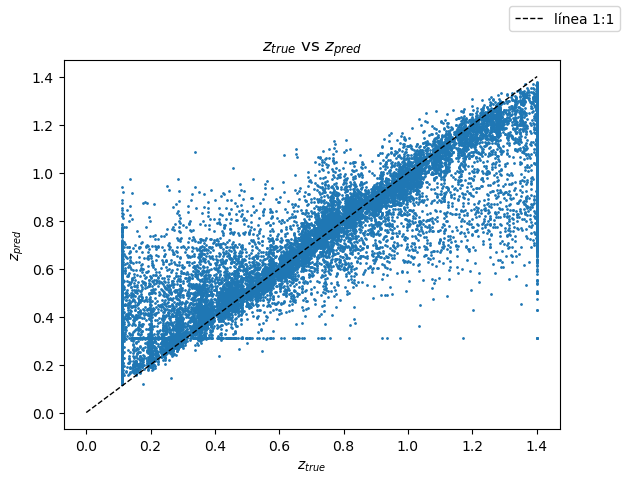

In [24]:
ypred = best_model.predict(X2)
fig, ax = plt.subplots()

ax.scatter(y2,ypred, s=1)
ax.plot([0, y2.max()], [0, y2.max()], 'k--', lw=1, label='línea 1:1')

ax.set(title=r"$z_{true}$ vs $z_{pred}$" ,xlabel=r"$z_{true}$", ylabel=r"$z_{pred}$")
fig.legend()
plt.show()

Notamos que en los bordes el modelo se comporta de una forma particular, aglomerando un notable conjunto de datos en $z_{pred} \approx 0.3$  y dispersando otros en los extremos de $z_{true}$.

## Realizando predicciones

In [ ]:
test_data = pd.read_csv("test_redshift.csv")
test_data.describe() #vizualización de estadísticas de datos relevantes

,objno_deep2,ra_deep2,dec_deep2,zquality,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor,flag_cfhtls,cfhtls_source,subaru_source
count,4.765000e+03,4765.000000,4765.000000,4765.000000,4765.000000,4765.000000,4765.000000,4765.000000,4765.000000,4765.000000,4765.000000,4765.000000,4765.000000
mean,1.250152e+07,214.787261,52.807192,3.107030,22.862070,21.982321,21.399592,20.943217,-22.517721,20.721557,20.309759,-2.058762,-48.950892
std,9.758642e+05,0.599941,0.411701,1.299698,21.952019,21.334297,21.288446,21.254146,59.634155,21.267251,73.853190,15.321859,49.647381
min,1.100202e+07,213.481999,51.928013,-2.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000
25%,1.200842e+07,214.321433,52.478780,2.000000,23.680232,23.249937,22.591230,22.011884,-99.000000,21.714441,0.000000,0.000000,-99.000000
50%,1.300432e+07,214.789663,52.819544,4.000000,24.311345,23.909306,23.411881,22.905968,21.918130,22.616402,0.000000,0.000000,0.000000
75%,1.304427e+07,215.242154,53.106055,4.000000,25.004287,24.429685,23.881083,23.475093,23.218497,23.266525,0.000000,1.000000,0.000000
max,1.410154e+07,216.079715,53.693236,4.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,253.000000,1.000000,1.000000


### Preprocesamiento de los datos, convirtiendo valores inválidos a NaN.

In [30]:
input_data=test_data.replace({-99.0:np.nan,99.0:np.nan})[cols[0:-2]+["z_apercor","zquality"]]
obj_label = test_data["objno_deep2"]
input_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4765 entries, 0 to 4764
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   u_apercor  4553 non-null   float64
 1   g_apercor  4573 non-null   float64
 2   r_apercor  4573 non-null   float64
 3   i_apercor  4573 non-null   float64
 4   z_apercor  4572 non-null   float64
 5   zquality   4765 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 223.5 KB


## Predicciones finales

In [31]:
predictions=best_model.predict(input_data)

### Exportación de nuestras predicciones

In [35]:
output = pd.DataFrame({"objno_deep2":obj_label,"z_pred":predictions})
output.to_csv("predicciones.csv",index=False)

### Obtención de métricas para Decision Tree

No estuvo presente en nuestro flujo de trabajo, por lo tanto lo calculamos ahora.

In [36]:
arbol = cross_validate(DecisionTreeRegressor(random_state=8000),X2,y2,cv=cv,scoring=scorings, return_train_score=True)
for key,value in arbol.items():
    print(f"{key} : {abs(value.mean()):.3f}")

fit_time : 0.128
score_time : 0.005
test_mse : 0.130
train_mse : 0.003
test_nmad : 0.078
train_nmad : 0.000
test_outlier : 0.258
train_outlier : 0.011


| Modelo        | Features usadas | Hiperparámetros principales | MSE train | MSE validación |
| ------------- | --------------- | --------------------------- | --------- | -------------- |
| Decision Tree | 1.Todas las bandas de fotometría y z_quality <br>2.Todas las bandas de fotometría y z_quality exceptuando i2 | RandomState | 0.003 | 0.130 |
| HistGradientBoosting | Todas las bandas de fotometría y z_quality exceptuando i2 | RandomState | 0.057 | 0.071 |
| GradientBoosting | Todas las bandas de fotometría y z_quality exceptuando i2 | RandomState | 0.075 | 0.079 |
| RandomForest | Todas las bandas de fotometría y z_quality exceptuando i2 | max_depth <br>min_samples_split <br>min_samples_leaf <br>n_estimators <br>warm_start | 0.035 | 0.069 |

### Análisis de las métricas obtenidas

El árbol de decisión de _Baseline_ está bastante sobreajustado.

`HistGradientBoosting` tiene un mejor desempeño que `GradientBoosting`.

`RandomForest` puede estar sobreajustado.

### Variables más relevantes

Usamos la herramienta de `permutarion_importance` de `sklearn`.

In [43]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best_model, X2, y2, n_repeats=10, random_state=0, scoring='neg_mean_squared_error')

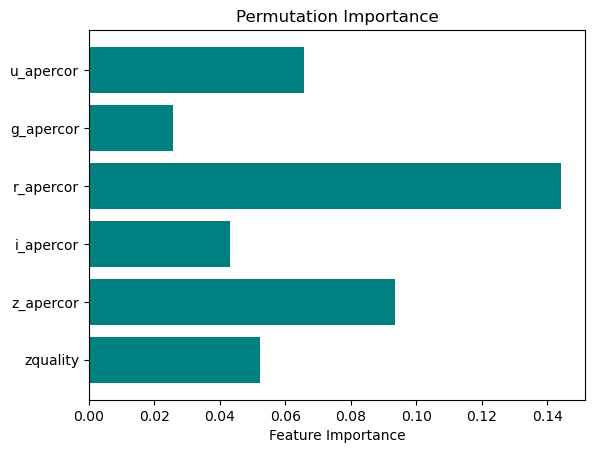

In [52]:
fig, ax = plt.subplots()
ax.barh(X2.columns,perm.importances_mean, color='teal')
ax.set(title="Permutation Importance",xlabel="Feature Importance")
ax.yaxis.set_inverted(True)
plt.show()

Con las herramientas de `Scikit Learn` es fácil notar que `r_apercor` tiene la mayor relevancia. Nuestra sospecha es que esta banda podría ser la más sensible al fenómeno de corrimiento al rojo. 
La poca relevancia de `i_apercor` nos podría sugerir que `i2_apercor` no sería contribuiría de forma notoria a nuestros resultados.
Tambíen podemos destacar que el modelo es sensible a `z_quality`, esto nos podría indicar la presencia de algún sesgo relacionado a esta _Feature_.

### Conclusión sobre modelo final escogido

Para nuesto modelo final (RandomForest con los parámetros ya explorados) conseguimos mejorar las métricas de evaluación. Sin embargo, existe la posibilidad de que nuestro modelo se encuentre algo sobreajustado, pues los valores de entrenamiento siguen siendo sospechosamente bajos, a pesar de que generaliza más.

## Preguntas finales

**Sobre la comparación de modelos:**

1. ¿Qué modelo obtuvo el menor MSE en validación?

<p style="color:royalblue">Nuestro modelo final de <i>Random Forest</i>. Sin embargo, antes de optimizar hiperparámetros el modelo con menor MSE era <i>Histogram-Based Gradient Boosting</i>.</p>

2. ¿Ese modelo fue elegido como modelo final? Justifiquen.

<p style="color:royalblue">Nuestro modelo final de <i>Random Forest</i>. En primera instancia, su MSE era más alto, pero, el resto de métricas eran mejores, esto nos llevó a explorar un espacio de hiperparámetros, obtiendo un mejor resultado de MSE.</p>

3. ¿Qué diferencias observaron entre un árbol individual y los métodos de ensamble?

<p style="color:royalblue">Un árbol individual se sobreajusta completamente, pero los métodos de ensamble, al ser mejor distribuidos, mantienen un cierto nivel de generalidad.<p>

**Sobre las variables:**

4. ¿Qué variables parecen ser más importantes para predecir el redshift?

<p style="color:royalblue">Parece ser más importante la fotometría de las bandas <i>r</i> y <i>z</i>.<p>

5. Calculen la importancia de variables con al menos dos criterios distintos (por ejemplo, MDI y permutation importance). ¿Coinciden en el ranking? Si no coinciden, ¿a qué atribuyen la diferencia?

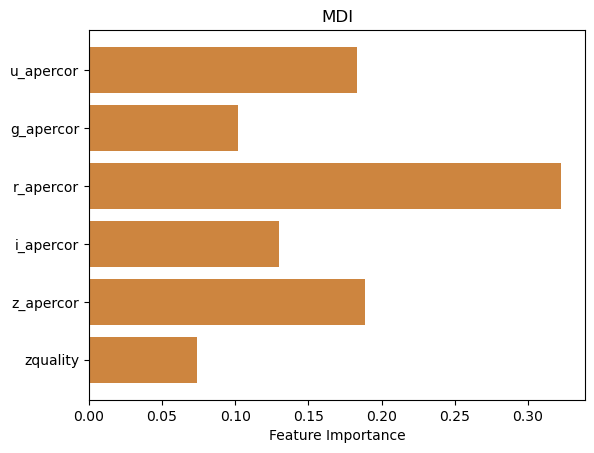

In [51]:
fig, ax = plt.subplots()
ax.barh(X2.columns,best_model.feature_importances_, color='peru')
ax.set(title="MDI",xlabel="Feature Importance")
ax.yaxis.set_inverted(True)
plt.show()

<p style="color:royalblue">Comparando, el ranking cambia. <code>u_apercor</code> gana importancia y <code>z_quality</code> pierde importancia. Esta difencia se debe a que MDI se encuentra sesgado a varaibles ruidosas.<p>

**Sobre los errores del modelo:**

6. ¿En qué rangos de redshift falla más el modelo?

<p style="color:royalblue">Falla más en los extremos. Y, posee una cierta tendencia a predecir un <i>redshift</i> de 0.3</p>

7. En el notebook de clase vimos que los métodos basados en árboles tienden a "estrechar" la distribución de predicciones (sobreestiman z bajos, subestiman z altos). ¿Observan este mismo efecto en su propio scatter $z_{\rm true}$
 vs. $z_{\rm pred}$? ¿En qué rango es más pronunciado, y coincide con una menor cantidad de galaxias de entrenamiento en ese rango?

In [54]:
edges= (y2 < 0.11) | (y2>1.39)
len(y2[edges])/len(y2) #porcentaje de la muestra en los extremos de la distribución

0.05495169082125604

<p style="color:royalblue">Sí obsevamos este efecto, pues obsevamos que una cantidad pequeña (~5%) se encuentra en los extremos de la distribución. El efecto parece ser más notorio en un rango bajo de valores de <i>z</i><p>

8. Si usaron oob_score en algún modelo, comparen ese valor con el de su validación cruzada. ¿Son consistentes? ¿Qué les dice eso sobre la confiabilidad de OOB para este dataset en particular?

<p style="color:royalblue">No utilizamos <code>oob_score</code>, por lo que no podemos hacer el análisis.</p>

**Sobre el proceso:**

9. ¿Qué posibles fuentes de error o sesgo puede tener este enfoque?

<p style="color:royalblue">El trabajar con datos existentes nos "encierra" en un rango de valores, por lo que no podemos identificar valores de <i>redshift</i> fuera del mismo. Además, estamos atados a la calidad de los datos.</p>

10. ¿Qué decisión metodológica tuvo mayor impacto en el resultado final?

<p style="color:royalblue">El mayor imparco en el resultado se debió a nuestra decisión de eliminar toda fila con NaN (en vez de rellenarlos), y además eliminar <i>outliers</p></p>

11. ¿El modelo con menor MSE es necesariamente el mejor modelo desde el punto de vista científico? Justifiquen.

<p style="color:royalblue">No, porque un bajo MSE podía implicar un sobreajuste. Esto es algo que ha pasado anteriormente en estudios científicos que tuvieron que ser descartados.</p>